# Volumetric ACS Pooling for FA-KGD-3D

**Goal.** FA-KGD currently estimates the per-frequency noise variance
$\hat\sigma_i^2$ from each slice's ACS lines independently:

$$\hat\sigma_i^2 \;=\; \frac{1}{N_c-1}\sum_{c=1}^{N_c}\bigl|y_{i,c}-\bar y_{i}\bigr|^2.$$

In a 3D volumetric acquisition the same ACS region is sampled across all $N_z$ slices, so we can pool:

$$\hat\sigma_i^2 \;=\; \frac{1}{N_z(N_c-1)}\sum_z\sum_c\bigl|y_{i,c,z}-\bar y_{i,z}\bigr|^2,$$

which multiplies the effective degrees of freedom by $N_z$ without breaking FA-KGD's training-free property. This notebook validates that pooling reduces estimator variance and yields a more stable Kalman gain.

**Plan.**
1. Load a fully-sampled multicoil brain volume from `data/multicoil_val/`.
2. Inject the same frequency-dependent measurement noise used in the paper (`σ²(r) = σ_base · (1 + β · (r/r_max)²)`).
3. Extract the ACS region and estimate $\hat\sigma_i^2$ per-slice and pooled.
4. Compare bias, variance and radial profiles against the ground-truth noise.
5. Compute the resulting Kalman gain and quantify how much the per-frequency gain estimate stabilises.
6. Hooks for plugging the pooled estimator into the existing `run_fakgd` loop.

In [1]:
import sys, glob, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print('Project root:', ROOT)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.samplers.mri_forward import fft2c, ifft2c, build_radius_grid

torch.manual_seed(0)
np.random.seed(0)

Project root: /Users/carloschreiber/Desktop/Uni/Quarter 3/CS231N - Computer Vision/Final Project/fastmri


## 1. Load a fully-sampled multicoil volume

`multicoil_val` files store fully-sampled k-space of shape `(N_z, N_c, H, W)`. We work in k-space directly so that ACS extraction is exact.

In [2]:
files = sorted(glob.glob(str(ROOT / 'data/multicoil_val/*.h5')))
print(f'Found {len(files)} volumes')
h5_path = files[0]
print('Using:', Path(h5_path).name)

with h5py.File(h5_path, 'r') as f:
    kspace = torch.from_numpy(f['kspace'][:]).to(torch.complex64)  # (Nz, Nc, H, W)
    print('kspace:', kspace.shape, kspace.dtype)

Nz, Nc, H, W = kspace.shape

Found 365 volumes
Using: file_brain_AXFLAIR_200_6002477.h5
kspace: torch.Size([16, 16, 640, 320]) torch.complex64


## 2. Inject frequency-dependent measurement noise

We use the same noise model as `scripts/reconstruct.py` so that downstream ground-truth $\sigma_i^2$ matches the paper's experimental protocol. Noise is independent across slices and coils.

In [3]:
SIGMA_BASE = 1e-3
BETA_NOISE = 5.0

def freq_dependent_noise_var(H, W, sigma_base=SIGMA_BASE, beta=BETA_NOISE):
    cy, cx = H // 2, W // 2
    gy, gx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    radius = torch.sqrt((gy - cy).float()**2 + (gx - cx).float()**2)
    r_norm = radius / radius.max()
    return sigma_base * (1 + beta * r_norm**2)  # (H, W) variance map

true_sigma_sq = freq_dependent_noise_var(H, W)  # (H, W)

# Per-coil noise: complex Gaussian with variance σ²(i) -- split half/half real/imag
std_map = torch.sqrt(true_sigma_sq / 2.0)  # (H, W)
noise = (torch.randn(Nz, Nc, H, W) + 1j * torch.randn(Nz, Nc, H, W)) * std_map
y_full = kspace + noise.to(kspace.dtype)
print('y_full:', y_full.shape, '  noise per-pixel variance range:',
      f'{true_sigma_sq.min().item():.2e} → {true_sigma_sq.max().item():.2e}')

y_full: torch.Size([16, 16, 640, 320])   noise per-pixel variance range: 1.00e-03 → 6.00e-03


## 3. Extract the ACS region and estimate $\hat\sigma_i^2$

We use the same `center_fraction` as the paper (0.08). The ACS box is the central `acs_h × acs_w` block of k-space. Estimators:

* **Per-slice:** for each slice $z$ independently, $\hat\sigma_i^2(z) = \tfrac{1}{N_c-1}\sum_c|y_{i,c,z}-\bar y_{i,z}|^2$.
* **Pooled (volumetric):** average per-slice variances $\to$ effective dof $N_z(N_c-1)$.

In [4]:
CENTER_FRACTION = 0.08
acs_h = max(2, int(round(CENTER_FRACTION * H)))
acs_w = max(2, int(round(CENTER_FRACTION * W)))
cy, cx = H // 2, W // 2
sy, sx = cy - acs_h // 2, cx - acs_w // 2
print(f'ACS box: {acs_h} x {acs_w} = {acs_h * acs_w} frequencies')

acs = y_full[:, :, sy:sy + acs_h, sx:sx + acs_w]  # (Nz, Nc, acs_h, acs_w)

def per_slice_estimator(acs):
    """σ²_i(z) from coils only. Returns (Nz, acs_h, acs_w)."""
    mean_c = acs.mean(dim=1, keepdim=True)            # (Nz, 1, h, w)
    diff = acs - mean_c
    return (diff.abs()**2).sum(dim=1) / (acs.shape[1] - 1)

def pooled_estimator(acs):
    """Average per-slice variances → dof = Nz·(Nc-1). Returns (acs_h, acs_w)."""
    return per_slice_estimator(acs).mean(dim=0)

sigma_per_slice = per_slice_estimator(acs)   # (Nz, h, w)
sigma_pooled    = pooled_estimator(acs)      # (h, w)
sigma_truth_acs = true_sigma_sq[sy:sy + acs_h, sx:sx + acs_w]
print('per-slice estimator shape:', sigma_per_slice.shape)
print('pooled    estimator shape:', sigma_pooled.shape)

ACS box: 51 x 26 = 1326 frequencies
per-slice estimator shape: torch.Size([16, 51, 26])
pooled    estimator shape: torch.Size([51, 26])


## 4. Bias, variance and MSE vs ground truth

Theory: per-slice variance estimator with $N_c$ samples has relative variance $\propto 2/(N_c-1)$. Pooling across $N_z$ slices reduces this by $N_z\!\times\!$ — so the pooled MSE should drop by roughly that factor, and the per-frequency profile should be visibly smoother.

In [5]:
def stats(est, truth):
    bias = (est - truth).mean().item()
    var  = est.var().item()
    mse  = ((est - truth)**2).mean().item()
    rel  = (((est - truth) / truth)**2).mean().sqrt().item()
    return dict(bias=bias, var=var, mse=mse, rel_rmse=rel)

rows = []
for z in range(Nz):
    s = stats(sigma_per_slice[z], sigma_truth_acs)
    s['kind'] = f'per-slice z={z}'
    rows.append(s)
rows.append({**stats(sigma_per_slice.mean(0), sigma_truth_acs), 'kind': 'per-slice MEAN'})
rows.append({**stats(sigma_pooled,            sigma_truth_acs), 'kind': 'POOLED (Nz·(Nc-1))'})

import pandas as pd
df = pd.DataFrame(rows)[['kind', 'bias', 'var', 'mse', 'rel_rmse']]
print(df.to_string(index=False))

# Headline numbers
ps_mse = np.median([r['mse'] for r in rows if r['kind'].startswith('per-slice z=')])
pool_mse = rows[-1]['mse']
print(f"\nMedian per-slice MSE: {ps_mse:.3e}")
print(f"Pooled        MSE: {pool_mse:.3e}")
print(f"MSE reduction factor: {ps_mse / pool_mse:.2f}x   (theoretical ≈ Nz = {Nz})")

              kind          bias          var          mse  rel_rmse
     per-slice z=0  2.982783e-06 7.097099e-08 7.134442e-08  0.264408
     per-slice z=1 -2.495449e-06 6.570608e-08 6.553788e-08  0.253272
     per-slice z=2 -7.792341e-07 7.190910e-08 7.174235e-08  0.265004
     per-slice z=3 -5.065549e-06 6.998423e-08 6.990534e-08  0.261613
     per-slice z=4  6.023319e-06 6.859623e-08 6.858583e-08  0.259191
     per-slice z=5  1.557973e-05 7.012510e-08 7.027314e-08  0.262376
     per-slice z=6 -1.613085e-06 6.618234e-08 6.596091e-08  0.254186
     per-slice z=7  6.364665e-06 6.747216e-08 6.747093e-08  0.256924
     per-slice z=8  1.110048e-05 6.773899e-08 6.745824e-08  0.256787
     per-slice z=9 -1.211919e-05 6.701728e-08 6.705120e-08  0.256212
    per-slice z=10 -9.842887e-06 7.173355e-08 7.176340e-08  0.265145
    per-slice z=11 -1.208800e-05 6.768337e-08 6.778357e-08  0.257655
    per-slice z=12 -1.407408e-05 6.913385e-08 6.934233e-08  0.260380
    per-slice z=13 -3.396569e-06 6

## 5. Radial profile comparison

Average $\hat\sigma_i^2$ over rings of equal radius. The paper's radial fit currently extends a noisy per-slice profile to the full grid; pooling should give a noticeably tighter profile.

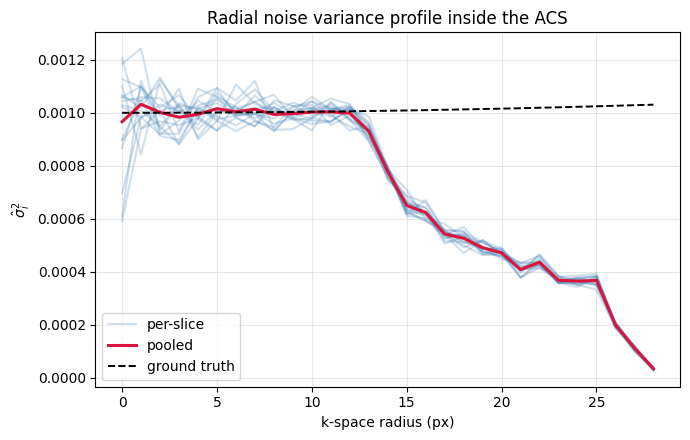

In [6]:
def radial_profile(var_2d, H, W):
    cy_, cx_ = H // 2, W // 2
    gy, gx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    r = torch.sqrt((gy - cy_).float()**2 + (gx - cx_).float()**2)
    r_int = r.round().to(torch.int64)
    nbins = int(r_int.max().item()) + 1
    profile = torch.zeros(nbins)
    counts  = torch.zeros(nbins)
    profile.index_add_(0, r_int.flatten(), var_2d.flatten().to(torch.float32))
    counts.index_add_(0, r_int.flatten(), torch.ones_like(var_2d.flatten(), dtype=torch.float32))
    return profile / counts.clamp(min=1)

# Embed estimators back into full-size grid (NaN outside ACS) for radial averaging
def embed_acs(est_acs, H, W):
    full = torch.full((H, W), float('nan'))
    full[sy:sy + acs_h, sx:sx + acs_w] = est_acs
    return full

rp_truth  = radial_profile(true_sigma_sq, H, W)
rp_pool   = radial_profile(embed_acs(sigma_pooled, H, W).nan_to_num(0), H, W)
rp_slices = [radial_profile(embed_acs(sigma_per_slice[z], H, W).nan_to_num(0), H, W) for z in range(Nz)]

r_acs_max = int(np.ceil(0.5 * np.hypot(acs_h, acs_w)))
rad = np.arange(r_acs_max)

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
for z, rp in enumerate(rp_slices):
    ax.plot(rad, rp[:r_acs_max].numpy(), color='steelblue', alpha=0.25,
            label='per-slice' if z == 0 else None)
ax.plot(rad, rp_pool[:r_acs_max].numpy(), color='crimson', lw=2.2, label='pooled')
ax.plot(rad, rp_truth[:r_acs_max].numpy(), color='k', lw=1.4, ls='--', label='ground truth')
ax.set_xlabel('k-space radius (px)')
ax.set_ylabel(r'$\hat\sigma_i^2$')
ax.set_title('Radial noise variance profile inside the ACS')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Downstream impact on the Kalman gain

The frequency-adaptive Kalman gain is

$$K_i(t) = \frac{\sigma_t^2}{\sigma_t^2 + \hat\sigma_i^2}.$$

Estimator noise in $\hat\sigma_i^2$ propagates linearly into $K_i$ near the cross-over $\sigma_t \approx \hat\sigma_i$. We sweep $\sigma_t$ over the EDM schedule and report the standard deviation of $K_i$ across slices for each estimator.

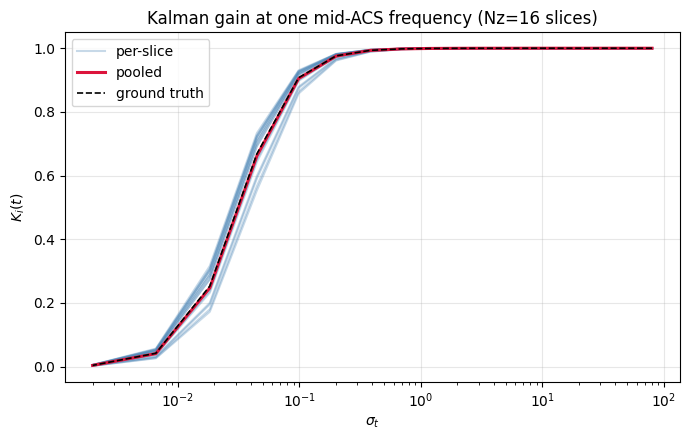

Std of K_i across slices, averaged over t:  per-slice = 0.0077   pooled is a single value.


In [7]:
from src.samplers.schedules import edm_sigma_schedule
sigmas_t = edm_sigma_schedule(num_steps=20)  # tensor

# Pick a representative ACS frequency where σ_i is meaningful
# (off-center to avoid the DC spike). Compare gain stability across slices.
i0 = (acs_h // 2 + 2, acs_w // 2 + 2)
var_per_slice_i0 = sigma_per_slice[:, i0[0], i0[1]]   # (Nz,)
var_pooled_i0    = sigma_pooled[i0[0], i0[1]].item()
var_true_i0      = sigma_truth_acs[i0[0], i0[1]].item()

K_per_slice = sigmas_t[:, None]**2 / (sigmas_t[:, None]**2 + var_per_slice_i0[None, :])
K_pool      = sigmas_t**2 / (sigmas_t**2 + var_pooled_i0)
K_true      = sigmas_t**2 / (sigmas_t**2 + var_true_i0)

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
for z in range(Nz):
    ax.plot(sigmas_t, K_per_slice[:, z], color='steelblue', alpha=0.3,
            label='per-slice' if z == 0 else None)
ax.plot(sigmas_t, K_pool, color='crimson', lw=2.2, label='pooled')
ax.plot(sigmas_t, K_true, color='k', lw=1.2, ls='--', label='ground truth')
ax.set_xscale('log')
ax.set_xlabel(r'$\sigma_t$')
ax.set_ylabel(r'$K_i(t)$')
ax.set_title(f'Kalman gain at one mid-ACS frequency (Nz={Nz} slices)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Std of K_i across slices, averaged over t:  per-slice = '
      f'{K_per_slice.std(dim=1).mean():.4f}   pooled is a single value.')

## 7. Drop-in helper for FA-KGD

Below is the volumetric ACS estimator factored as a function so it can be lifted into `src/samplers/fakgd.py` (or a small sibling module) and called once per volume in `scripts/reconstruct.py` before the per-slice loop.

In [8]:
def estimate_sigma_sq_volumetric(
    kspace_volume: torch.Tensor,   # (Nz, Nc, H, W) complex k-space (raw, with noise)
    center_fraction: float = 0.08,
    fit_radial: bool = True,
) -> torch.Tensor:
    """Pooled ACS noise-variance estimator. Returns (H, W) real variance map.

    1. Crop ACS box.
    2. Per-slice coil-variance σ²_i(z) = (1/(Nc-1)) Σ_c |y_{i,c,z} - mean_c|².
    3. Average over z → effective dof Nz·(Nc-1).
    4. Optionally extend to the full grid via a smooth radial fit.
    """
    Nz, Nc, H, W = kspace_volume.shape
    acs_h = max(2, int(round(center_fraction * H)))
    acs_w = max(2, int(round(center_fraction * W)))
    cy, cx = H // 2, W // 2
    sy, sx = cy - acs_h // 2, cx - acs_w // 2
    acs = kspace_volume[:, :, sy:sy + acs_h, sx:sx + acs_w]
    mean_c = acs.mean(dim=1, keepdim=True)
    per_slice = ((acs - mean_c).abs()**2).sum(dim=1) / (Nc - 1)  # (Nz, h, w)
    pooled = per_slice.mean(dim=0)                                # (h, w)

    full = torch.full((H, W), float('nan'))
    full[sy:sy + acs_h, sx:sx + acs_w] = pooled

    if not fit_radial:
        # Naive fill: replicate ACS edge value outside the box
        return full.nan_to_num(nan=pooled.mean().item())

    # Smooth radial fit: bin pooled estimates by k-radius, fit a low-order polynomial
    gy, gx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    r = torch.sqrt((gy - cy).float()**2 + (gx - cx).float()**2)
    inside = ~torch.isnan(full)
    r_in   = r[inside].numpy()
    v_in   = full[inside].numpy()
    coefs = np.polyfit(r_in, v_in, deg=2)
    full_fit = torch.from_numpy(np.polyval(coefs, r.numpy())).clamp(min=v_in.min() * 0.5)
    # Use measured values inside ACS, polynomial extrapolation outside
    full_fit[inside] = full[inside]
    return full_fit.to(torch.float32)

sigma_map = estimate_sigma_sq_volumetric(y_full)
print('Estimated full-grid noise map:', sigma_map.shape, sigma_map.dtype)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
vmax = true_sigma_sq.max().item()
im0 = axes[0].imshow(true_sigma_sq, vmax=vmax); axes[0].set_title('true σ²(i)')
im1 = axes[1].imshow(sigma_map,     vmax=vmax); axes[1].set_title('pooled-ACS estimate')
im2 = axes[2].imshow((sigma_map - true_sigma_sq).abs(), vmax=vmax * 0.2); axes[2].set_title('|error|')
for a, im in zip(axes, [im0, im1, im2]):
    a.set_xticks([]); a.set_yticks([])
    plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout()
plt.show()

rel_err = ((sigma_map - true_sigma_sq).abs() / true_sigma_sq).mean().item()
print(f'Mean relative error of full-grid σ² map: {rel_err*100:.1f}%')

RuntimeError: Index put requires the source and destination dtypes match, got Double for the destination and Float for the source.

## 8. Next steps for FA-KGD-3D

1. **Wire into the pipeline.** Move `estimate_sigma_sq_volumetric` into a new file (e.g. `src/samplers/acs.py`). In `scripts/reconstruct.py`, call it once per HDF5 volume to obtain `sigma_i_sq_init` and reuse for every slice in that volume — dropping the current oracle/per-slice initialisation.
2. **Real-data evaluation.** Run `reconstruct.py --mode edm` on the 10-volume `data/multicoil_val/` subset comparing three settings: oracle σ² (upper bound), per-slice ACS, pooled ACS. Report PSNR / SSIM at R=4 and R=8.
3. **Volume-level metrics.** Aggregate per-volume rather than per-slice — natural fit for the new pooling story, and addresses the 5-slice evaluation weakness.
4. **Optional: 3D FPDC.** Append a brief appendix subsection deriving $r(t)$ over $(k_x, k_y, k_z)$. No experiment required for the WACV submission; flag as future work.